# 05 — Phase 2 v0: Feature Pipeline

Builds the first ML-ready feature snapshot for delay prediction. Loads the
GTFS-RT `trip_updates` archive and the static GTFS archive from S3, joins them
on `(trip_id, stop_id)` to attach the schedule that was actually in effect on
each realtime date, engineers time/mode features, and writes the result to a
new S3 prefix (`ml_features/v0_feature_snapshot/`).

This is a pipeline-building step — **no model training happens in this
notebook**. Raw archives under `gtfs_realtime/` and `gtfs_static/` are only
ever read, never written to.

In [1]:
# Cell 0 — Environment setup: load .env, configure S3 access
import os
import subprocess
import sys
from pathlib import Path

try:
    from dotenv import load_dotenv, find_dotenv
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'python-dotenv', '-q'], check=True)
    from dotenv import load_dotenv, find_dotenv

try:
    import s3fs
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 's3fs', '-q'], check=True)
    import s3fs

_dotenv_path = find_dotenv(usecwd=True)
if _dotenv_path:
    load_dotenv(_dotenv_path, override=False)
    print(f'Loaded .env from: {_dotenv_path}')
else:
    print('No .env file found — using defaults.')

S3_BUCKET = os.environ.get('AWS_S3_BUCKET', '')
AWS_REGION = os.environ.get('AWS_REGION', 'ap-southeast-2')
REPO_DIR   = os.environ.get('TRANSIT_AI_REPO_DIR', str(Path.cwd().parent))

if not S3_BUCKET:
    raise EnvironmentError('AWS_S3_BUCKET is not set. Check your .env file.')

assert S3_BUCKET == 'seq-transit-ai-data-ps', (
    f'Expected bucket seq-transit-ai-data-ps, got {S3_BUCKET!r}'
)

fs = s3fs.S3FileSystem()

print(f'S3_BUCKET: {S3_BUCKET}')
print(f'AWS_REGION: {AWS_REGION}')
print(f'REPO_DIR: {REPO_DIR}')

Loaded .env from: /Users/proteeksanyal/Desktop/Learning/Transit-AI/.env
S3_BUCKET: seq-transit-ai-data-ps
AWS_REGION: ap-southeast-2
REPO_DIR: /Users/proteeksanyal/Desktop/Learning/Transit-AI


## Step 2 — GTFS-RT `trip_updates` coverage

List every `YYYY-MM-DD` folder under `gtfs_realtime/trip_updates/` and count
snapshot files per day, so we know actual coverage before anything downstream
runs.

In [2]:
# Cell 1 — List available trip_updates dates and snapshot file counts
import re

# Test-mode switch: restrict loading to a single date for a fast dry run.
# Set DATE_LIMIT = None to opt in to the full available date range.
DATE_LIMIT = '2026-07-05'

RT_PREFIX = f'{S3_BUCKET}/gtfs_realtime/trip_updates'
date_pattern = re.compile(r'^\d{4}-\d{2}-\d{2}$')

try:
    rt_entries = fs.ls(RT_PREFIX)
except Exception as e:
    raise FileNotFoundError(f'Cannot list s3://{RT_PREFIX}: {e}')

all_rt_dates = sorted([
    e.rstrip('/').split('/')[-1] for e in rt_entries
    if date_pattern.match(e.rstrip('/').split('/')[-1])
])

if not all_rt_dates:
    raise FileNotFoundError(
        f'No YYYY-MM-DD subfolders found under s3://{RT_PREFIX}.\n'
        'Run scripts/archive_gtfsrt.py first to start collecting trip_updates.'
    )

if DATE_LIMIT is not None:
    rt_dates = [d for d in all_rt_dates if d == DATE_LIMIT]
    if not rt_dates:
        raise ValueError(
            f'DATE_LIMIT={DATE_LIMIT!r} not found among available dates: {all_rt_dates}'
        )
    print(f'[TEST MODE] DATE_LIMIT={DATE_LIMIT!r} — restricting to 1 of {len(all_rt_dates)} available date(s)\n')
else:
    rt_dates = all_rt_dates
    print(f'DATE_LIMIT=None — loading full available range ({len(all_rt_dates)} date(s))\n')

rt_file_counts = {}
for d in rt_dates:
    files = [f for f in fs.ls(f'{RT_PREFIX}/{d}') if f.endswith('.json')]
    rt_file_counts[d] = len(files)

print(f'trip_updates coverage in scope: {rt_dates[0]} → {rt_dates[-1]}  ({len(rt_dates)} day(s))\n')
for d in rt_dates:
    print(f'  {d}: {rt_file_counts[d]:>4} snapshot files')

print(f'\nTotal snapshot files in scope: {sum(rt_file_counts.values()):,}')

[TEST MODE] DATE_LIMIT='2026-07-05' — restricting to 1 of 9 available date(s)

trip_updates coverage in scope: 2026-07-05 → 2026-07-05  (1 day(s))

  2026-07-05:   71 snapshot files

Total snapshot files in scope: 71


## Step 3 — Load static GTFS from S3

Load `trips.txt`, `stop_times.txt`, `routes.txt`, `calendar.txt` for a single,
explicitly chosen static snapshot — `STATIC_SNAPSHOT_DATE`, defined below.

In [3]:
# Cell 2 — Load static GTFS txt files for the selected snapshot
import pandas as pd

STATIC_PREFIX = f'{S3_BUCKET}/gtfs_static'

try:
    static_entries = fs.ls(STATIC_PREFIX)
except Exception as e:
    raise FileNotFoundError(f'Cannot list s3://{STATIC_PREFIX}: {e}')

static_dates = sorted([
    e.rstrip('/').split('/')[-1] for e in static_entries
    if date_pattern.match(e.rstrip('/').split('/')[-1])
])

if not static_dates:
    raise FileNotFoundError(
        f'No YYYY-MM-DD subfolders found under s3://{STATIC_PREFIX}.\n'
        'Run scripts/archive_gtfsrt.py (static download) first.'
    )

# Explicit, deliberate choice of which static schedule to join against.
# Default: auto-detect the most recent available snapshot. Override with any
# value from `static_dates` printed below to pin a specific schedule version.
STATIC_SNAPSHOT_DATE = max(static_dates)

print(f'Static GTFS snapshots available: {static_dates}')
print(f'>>> Using static snapshot: {STATIC_SNAPSHOT_DATE} <<<\n')

def load_static_txt(snapshot_date, name):
    s3_path = f's3://{STATIC_PREFIX}/{snapshot_date}/{name}'
    try:
        return pd.read_csv(s3_path, dtype=str)
    except FileNotFoundError:
        print(f'  {name} not found for {snapshot_date} — skipping')
        return None

trips      = load_static_txt(STATIC_SNAPSHOT_DATE, 'trips.txt')
stop_times = load_static_txt(STATIC_SNAPSHOT_DATE, 'stop_times.txt')
routes     = load_static_txt(STATIC_SNAPSHOT_DATE, 'routes.txt')
calendar   = load_static_txt(STATIC_SNAPSHOT_DATE, 'calendar.txt')

print(
    f'  trips={len(trips):,}, stop_times={len(stop_times):,}, '
    f'routes={len(routes):,}, calendar={len(calendar):,}'
)

Static GTFS snapshots available: ['2026-06-28', '2026-07-01']
>>> Using static snapshot: 2026-07-01 <<<



  trips=139,413, stop_times=3,509,446, routes=1,281, calendar=174


## Step 3b — v0 uses one static snapshot, deliberately

Every realtime row is joined against **one** static GTFS snapshot —
`STATIC_SNAPSHOT_DATE` from the cell above — not the schedule version that
was actually in effect on each realtime date. This is a known, deliberate v0
simplification, not a bug: GTFS `trip_id` values are re-issued when TransLink
publishes a new static feed, so a realtime date joined against a schedule
from a different release can match anywhere from ~0% to ~99% depending on how
close the versions are (confirmed by hand: joining 2026-06-28 realtime data
against the 2026-07-01 schedule matched 0.0%; against the 2026-06-28 schedule
itself it matched 99.1%). Per-date schedule matching is a real improvement
for a later version — not implemented here. For now the goal is just to make
the choice visible and overridable instead of implicit.

## Step 4 — Load trip_updates and join against static `stop_times`

`stop_times.arrival_time` / `departure_time` use GTFS's `25:xx`-style
past-midnight times. These are **kept as strings** here — casting them
directly to `datetime` raises/wraps incorrectly for anything past 24:00 (this
bit us in an earlier notebook). `delay_seconds` in the realtime feed is
already the schedule deviation, so `delay_minutes` is simply
`delay_seconds / 60`; the static join exists to attach the scheduled time,
stop sequence, and route mode, and to drop any trip/stop pairs that aren't in
the applicable schedule at all.

In [4]:
# Cell 4 — Load trip_updates JSON snapshots into one DataFrame (shared thread pool, progress every 100 files)
import json
from concurrent.futures import ThreadPoolExecutor, as_completed

def _load_snapshot_file(path):
    with fs.open(path) as f:
        return json.load(f)

file_manifest = []
for d in rt_dates:
    files = sorted([f for f in fs.ls(f'{RT_PREFIX}/{d}') if f.endswith('.json')])
    file_manifest.extend((d, f) for f in files)

total_files = len(file_manifest)
print(f'Fetching {total_files:,} snapshot file(s) from S3 (shared pool, 12 workers)...')

all_records = []
completed = 0
with ThreadPoolExecutor(max_workers=12) as executor:
    future_to_date = {
        executor.submit(_load_snapshot_file, fpath): d
        for d, fpath in file_manifest
    }
    for fut in as_completed(future_to_date):
        d = future_to_date[fut]
        recs = fut.result()
        for r in recs:
            r['source_date'] = d
        all_records.extend(recs)
        completed += 1
        if completed % 100 == 0 or completed == total_files:
            print(f'  Fetched {completed}/{total_files}')

trip_updates = pd.DataFrame(all_records)
del all_records

print(f'\nTotal trip_update records loaded: {len(trip_updates):,}')
print(trip_updates.dtypes)

Fetching 71 snapshot file(s) from S3 (shared pool, 12 workers)...


  Fetched 71/71



Total trip_update records loaded: 836,584
trip_id           object
route_id          object
stop_id           object
delay_seconds    float64
timestamp          int64
source_date       object
dtype: object


In [5]:
# Cell 5 — Join against the selected static stop_times + routes; compute delay_minutes
st = stop_times[['trip_id', 'stop_id', 'arrival_time', 'stop_sequence']].rename(
    columns={'arrival_time': 'scheduled_arrival_time'}
)
routes_subset = routes[['route_id', 'route_type']]

feature_df = trip_updates.merge(st, on=['trip_id', 'stop_id'], how='inner')
feature_df = feature_df.merge(routes_subset, on='route_id', how='left')

feature_df['stop_sequence'] = pd.to_numeric(feature_df['stop_sequence'], errors='coerce').astype('Int64')
feature_df['delay_minutes'] = pd.to_numeric(feature_df['delay_seconds'], errors='coerce') / 60

match_pct = 100 * len(feature_df) / len(trip_updates)
print(f'Joined against static snapshot {STATIC_SNAPSHOT_DATE}: '
      f'{len(trip_updates):,} rt rows -> {len(feature_df):,} matched to schedule ({match_pct:.1f}%)')
print(f'Rows after schedule join: {len(feature_df):,} '
      f'(dropped {len(trip_updates) - len(feature_df):,} unmatched trip/stop pairs)')

Joined against static snapshot 2026-07-01: 836,584 rt rows -> 833,047 matched to schedule (99.6%)
Rows after schedule join: 833,047 (dropped 3,537 unmatched trip/stop pairs)


## Step 5 — Feature engineering

`snapshot_timestamp` is converted to `Australia/Brisbane` local time (fixed
UTC+10, no daylight saving) before deriving `hour_of_day` / `is_peak`, since
peak windows are defined in local clock time. `mode` is derived from the
static `routes.txt` `route_type` (0/2/3/4 → tram/rail/bus/ferry) rather than a
`route_id` text prefix — a quick check showed prefixes aren't reliable (e.g.
`R773-4904` is a bus route, `GYBR-4975` is rail; there's no consistent
letter/digit convention), while `route_type` is the GTFS-authoritative
field.

In [6]:
# Cell 6 — Time and mode features
BRISBANE_TZ = 'Australia/Brisbane'

feature_df['snapshot_timestamp'] = pd.to_datetime(
    feature_df['timestamp'], unit='s', utc=True
).dt.tz_convert(BRISBANE_TZ)

feature_df['hour_of_day'] = feature_df['snapshot_timestamp'].dt.hour
feature_df['day_of_week'] = feature_df['snapshot_timestamp'].dt.day_name()
feature_df['is_weekend'] = feature_df['day_of_week'].isin(['Saturday', 'Sunday'])

is_am_peak = feature_df['hour_of_day'].between(7, 8)    # 7:00-8:59
is_pm_peak = feature_df['hour_of_day'].between(16, 17)  # 16:00-17:59
feature_df['is_peak'] = (~feature_df['is_weekend']) & (is_am_peak | is_pm_peak)

MODE_BY_ROUTE_TYPE = {'0': 'tram', '2': 'rail', '3': 'bus', '4': 'ferry'}
feature_df['mode'] = feature_df['route_type'].map(MODE_BY_ROUTE_TYPE).fillna('unknown')

print('mode value counts:')
print(feature_df['mode'].value_counts())
print('\nis_peak value counts:')
print(feature_df['is_peak'].value_counts())
print('\nis_weekend value counts:')
print(feature_df['is_weekend'].value_counts())

mode value counts:
mode
bus      719552
rail     101880
ferry     11615
Name: count, dtype: int64

is_peak value counts:
is_peak
False    833047
Name: count, dtype: int64

is_weekend value counts:
is_weekend
True    833047
Name: count, dtype: int64


## Step 6 — Write feature snapshot to a new S3 prefix

Written to `s3://seq-transit-ai-data-ps/ml_features/v0_feature_snapshot/` —
a brand new prefix. `gtfs_realtime/` and `gtfs_static/` are only read from
above, never written to.

In [7]:
# Cell 7 — Write engineered features to S3 as Parquet
FEATURE_COLUMNS = [
    'trip_id', 'route_id', 'stop_id', 'mode',
    'snapshot_timestamp', 'source_date',
    'scheduled_arrival_time', 'stop_sequence',
    'delay_seconds', 'delay_minutes',
    'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak',
]

output_df = feature_df[FEATURE_COLUMNS].copy()

ML_FEATURES_PREFIX = f'{S3_BUCKET}/ml_features/v0_feature_snapshot'
output_path = f's3://{ML_FEATURES_PREFIX}/features.parquet'

output_df.to_parquet(output_path, index=False)

print(f'Wrote {len(output_df):,} rows x {output_df.shape[1]} cols -> {output_path}')
print(f'\nRaw archives untouched: s3://{S3_BUCKET}/gtfs_realtime/ and s3://{S3_BUCKET}/gtfs_static/')

Wrote 833,047 rows x 14 cols -> s3://seq-transit-ai-data-ps/ml_features/v0_feature_snapshot/features.parquet

Raw archives untouched: s3://seq-transit-ai-data-ps/gtfs_realtime/ and s3://seq-transit-ai-data-ps/gtfs_static/


## Step 7 — Summary stats and coverage check

SUMMARY — v0 feature snapshot
Row count       : 833,047
Columns         : 14
Date range      : 2026-07-05 -> 2026-07-05

Null % per column:


trip_id                   0.00
route_id                  0.00
stop_id                   0.00
mode                      0.00
snapshot_timestamp        0.00
source_date               0.00
scheduled_arrival_time    0.00
stop_sequence             0.00
delay_seconds             2.71
delay_minutes             2.71
hour_of_day               0.00
day_of_week               0.00
is_weekend                0.00
is_peak                   0.00


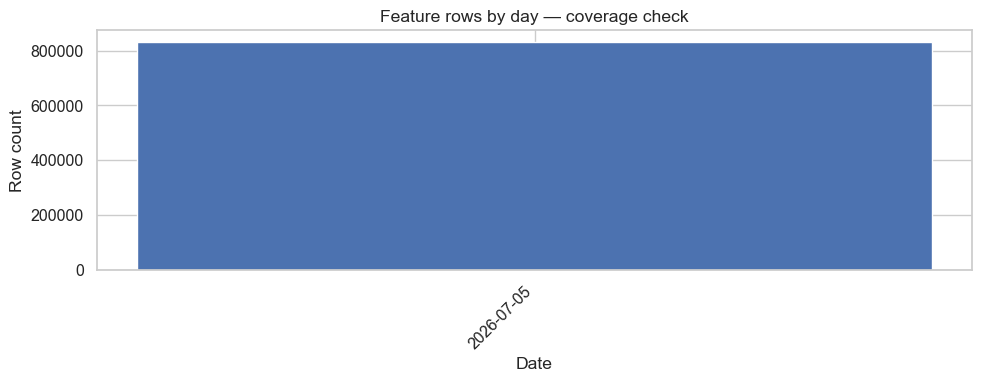

In [8]:
# Cell 8 — Summary: row count, date range, null %, row count by day
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 100

print('=' * 70)
print('SUMMARY — v0 feature snapshot')
print('=' * 70)
print(f'Row count       : {len(output_df):,}')
print(f'Columns         : {output_df.shape[1]}')
print(f'Date range      : {output_df["source_date"].min()} -> {output_df["source_date"].max()}')
print()
print('Null % per column:')
null_pct = (output_df.isnull().mean() * 100).round(2)
print(null_pct.to_string())

counts_by_day = output_df['source_date'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(counts_by_day.index, counts_by_day.values, color='#4C72B0')
ax.set_title('Feature rows by day — coverage check')
ax.set_xlabel('Date')
ax.set_ylabel('Row count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()